# UCI Adult Dataset - Complete Exploratory Data Analysis (EDA)
### Risk-Aware Dynamic Model Router (R3) - Base Exploratory & Diagnostic Suite

This notebook performs a comprehensive EDA on the UCI Adult Census Income dataset ($N = 48,842$, $d = 14$).
It covers:
1. **Data Audit & Missing Value Discovery**
2. **Target Class Imbalance & Demographics Analysis**
3. **Continuous Feature Distributions, Skewness & Outliers**
4. **Categorical Feature Association (Cramér's V)**
5. **R3 Diagnostic Operating Window Diagnostics** ($\Delta_{\text{Oracle}}$ & $\bar{\rho}_e$)

In [1]:
# --- 1. Load Libraries & Dataset ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print('Fetching UCI Adult dataset from OpenML...')
adult = fetch_openml(data_id=1590, as_frame=True, parser='auto')
df = adult.frame.copy()

print(f'Dataset Shape: {df.shape}')
df.head()

Fetching UCI Adult dataset from OpenML...
Dataset Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


--- Missing Values Profiling ---
                Missing Count  Percentage (%)
occupation               2809        5.751198
workclass                2799        5.730724
native-country            857        1.754637


/tmp/ipykernel_849/2495745599.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df['Percentage (%)'], y=missing_df.index, palette='Reds_r')


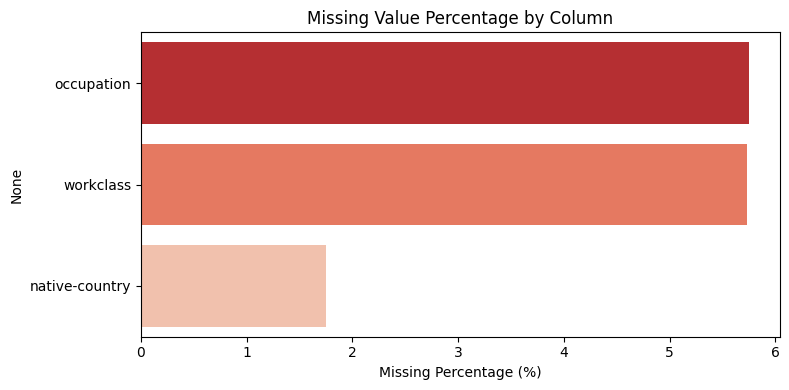

In [2]:
# --- 2. Data Cleaning & Missing Value Audit ---
target_col = 'class' if 'class' in df.columns else 'income'

# Replace '?' placeholder missing values with NaN
df.replace('?', np.nan, inplace=True)

missing_summary = df.isnull().sum()
missing_pct = (missing_summary / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage (%)': missing_pct
}).query('`Missing Count` > 0').sort_values(by='Missing Count', ascending=False)

print('--- Missing Values Profiling ---')
print(missing_df)

# Plot Missingness
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df['Percentage (%)'], y=missing_df.index, palette='Reds_r')
plt.title('Missing Value Percentage by Column')
plt.xlabel('Missing Percentage (%)')
plt.tight_layout()
plt.show()

--- Target Class Ratio (%) ---
class
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


/tmp/ipykernel_849/3905040304.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[0], palette='viridis')


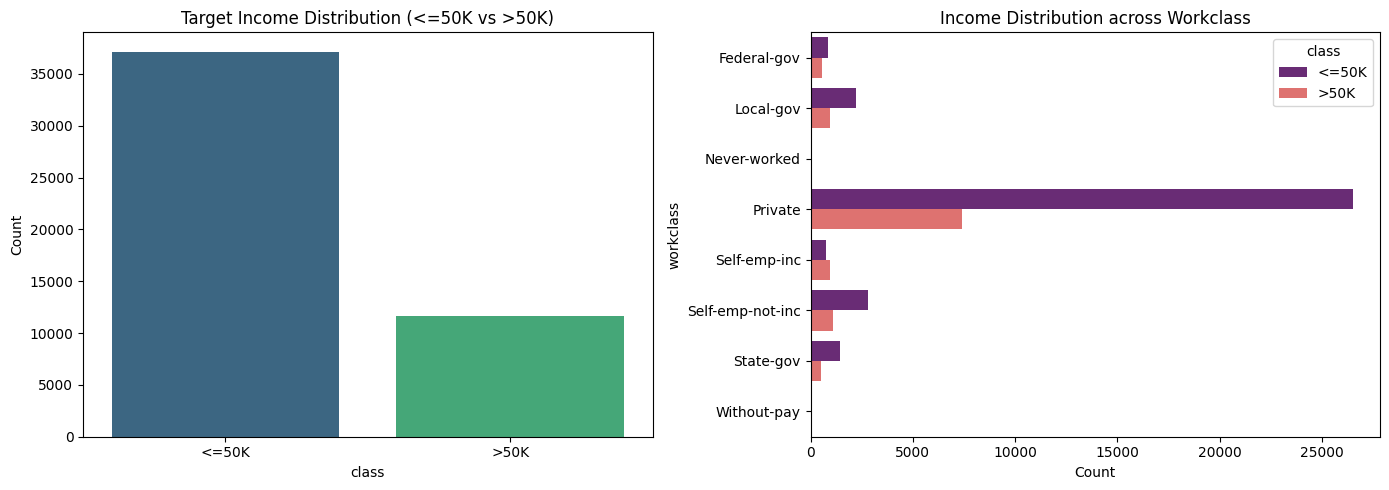

In [3]:
# --- 3. Target Class Imbalance & Categorical Distributions ---
class_dist = df[target_col].value_counts(normalize=True) * 100
print('--- Target Class Ratio (%) ---')
print(class_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Distribution
sns.countplot(data=df, x=target_col, ax=axes[0], palette='viridis')
axes[0].set_title('Target Income Distribution (<=50K vs >50K)')
axes[0].set_ylabel('Count')

# Workclass vs Income
sns.countplot(data=df, y='workclass', hue=target_col, ax=axes[1], palette='magma')
axes[1].set_title('Income Distribution across Workclass')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

--- Continuous Summary Statistics ---
                  count           mean            std      min       25%  \
age             48842.0      38.643585      13.710510     17.0      28.0   
fnlwgt          48842.0  189664.134597  105604.025423  12285.0  117550.5   
education-num   48842.0      10.078089       2.570973      1.0       9.0   
capital-gain    48842.0    1079.067626    7452.019058      0.0       0.0   
capital-loss    48842.0      87.502314     403.004552      0.0       0.0   
hours-per-week  48842.0      40.422382      12.391444      1.0      40.0   

                     50%       75%        max  
age                 37.0      48.0       90.0  
fnlwgt          178144.5  237642.0  1490400.0  
education-num       10.0      12.0       16.0  
capital-gain         0.0       0.0    99999.0  
capital-loss         0.0       0.0     4356.0  
hours-per-week      40.0      45.0       99.0  

--- Skewness Values ---
age                0.557580
fnlwgt             1.438892
education-nu

/tmp/ipykernel_849/968199543.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='hours-per-week', ax=axes[1], palette='Set2')


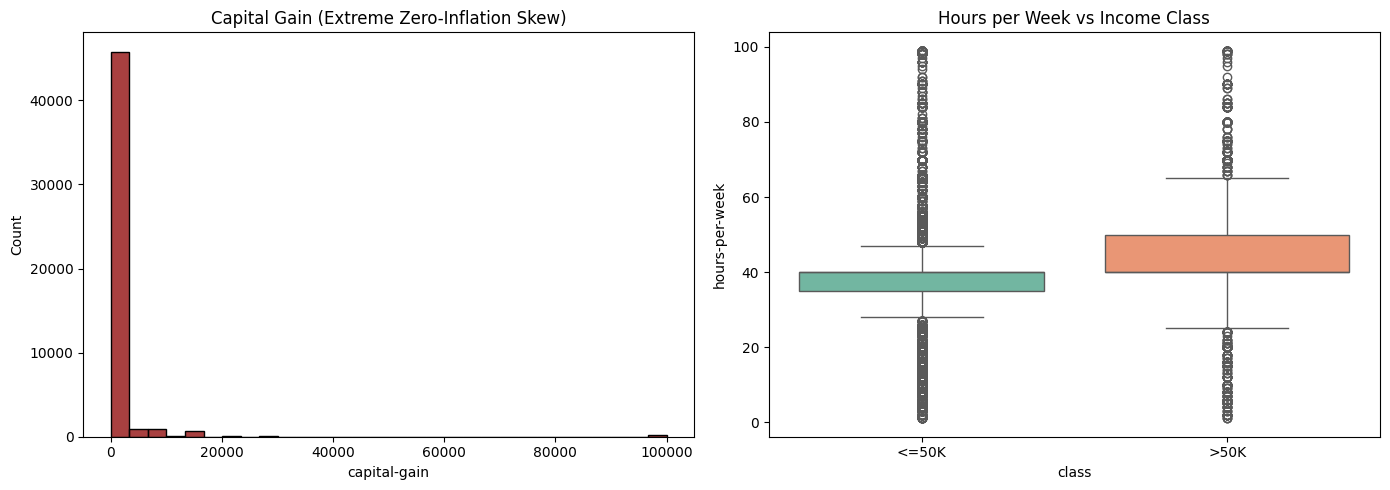

In [4]:
# --- 4. Continuous Feature Analysis & Skewness Profiling ---
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

print('--- Continuous Summary Statistics ---')
print(df[num_cols].describe().T)

print('\n--- Skewness Values ---')
print(df[num_cols].skew())

# Visualization of Skewed Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['capital-gain'], bins=30, ax=axes[0], color='darkred', kde=False)
axes[0].set_title('Capital Gain (Extreme Zero-Inflation Skew)')

sns.boxplot(data=df, x=target_col, y='hours-per-week', ax=axes[1], palette='Set2')
axes[1].set_title('Hours per Week vs Income Class')

plt.tight_layout()
plt.show()

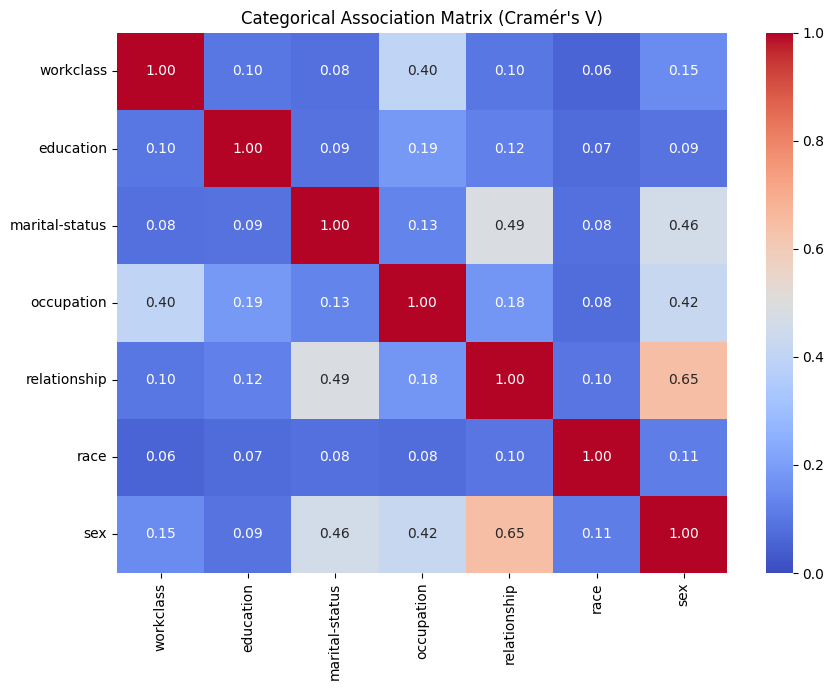

In [5]:
# --- 5. Categorical Association Matrix (Cramér's V) ---
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_list = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex']
corr_matrix = pd.DataFrame(index=cat_list, columns=cat_list, dtype=float)

for c1 in cat_list:
    for c2 in cat_list:
        corr_matrix.loc[c1, c2] = cramers_v(df[c1].astype(str), df[c2].astype(str))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title("Categorical Association Matrix (Cramér's V)")
plt.tight_layout()
plt.show()

In [6]:
# --- 6. R3 Diagnostic Operating Window Computation ---
X = df.drop(columns=[target_col])
y = (df[target_col].astype(str).str.contains('>50K')).astype(int).values

# Preprocessing setup
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object', 'category']).columns

num_tf = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_tf = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_tf, num_features), ('cat', cat_tf, cat_features)])

X_proc = preprocessor.fit_transform(X)

# 5-Fold Stratified Split for OOF Base Models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LR': LogisticRegression(max_iter=1000),
    'XGB': HistGradientBoostingClassifier(),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300, random_state=42)
}

oof_probs = {m: np.zeros((len(y), 2)) for m in models}

for train_idx, val_idx in skf.split(X_proc, y):
    X_tr, X_val = X_proc[train_idx], X_proc[val_idx]
    y_tr = y[train_idx]
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        oof_probs[name][val_idx] = model.predict_proba(X_val)

# Compute Failure Vectors and Performance Metrics
accs, failures = {}, {}
for name in models:
    preds = np.argmax(oof_probs[name], axis=1)
    accs[name] = accuracy_score(y, preds)
    failures[name] = (preds != y).astype(int)

# Oracle Headroom (Delta_Oracle)
oracle_correct = np.any([failures[m] == 0 for m in models], axis=0)
acc_oracle = np.mean(oracle_correct)
best_static_acc = max(accs.values())
delta_oracle = acc_oracle - best_static_acc

# Pairwise Error Correlation (rho_e)
rho_list = []
keys = list(models.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        r_i, r_j = failures[keys[i]], failures[keys[j]]
        rho_list.append(np.corrcoef(r_i, r_j)[0, 1])
avg_rho = np.mean(rho_list)

print('==================================================')
print('   UCI ADULT DATASET - R3 DIAGNOSTIC EVALUATION   ')
print('==================================================')
for m in models:
    print(f'Base Model Accuracy [{m}]: {accs[m]*100:.2f}%')
print(f'Best Static Model Acc     : {best_static_acc*100:.2f}%')
print(f'Oracle Upper Bound Acc    : {acc_oracle*100:.2f}%')
print(f'Oracle Headroom (Delta)   : {delta_oracle*100:.2f}%')
print(f'Pairwise Error Corr (rho) : {avg_rho:.3f}')
print('--------------------------------------------------')
if delta_oracle >= 0.03 and avg_rho <= 0.45:
    print('STATUS: PASS -> UCI Adult dataset is OPTIMAL for R3 Dynamic Routing')
else:
    print('STATUS: FAIL -> Static ensemble recommended')
print('==================================================')

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


   UCI ADULT DATASET - R3 DIAGNOSTIC EVALUATION   
Base Model Accuracy [LR]: 85.13%
Base Model Accuracy [XGB]: 87.35%
Base Model Accuracy [MLP]: 84.51%
Best Static Model Acc     : 87.35%
Oracle Upper Bound Acc    : 90.88%
Oracle Headroom (Delta)   : 3.52%
Pairwise Error Corr (rho) : 0.704
--------------------------------------------------
STATUS: FAIL -> Static ensemble recommended
